## FIGURES 5 and 7 for WUS CMIP6 WARMING PAPER

In [1]:
import netCDF4
#import h5netcdf
import xarray as xr
import scipy
import os
#os.environ['ESMFMKFILE'] = '/home/tessj/miniconda3/envs/xarrayxesmf/lib/esmf.mk'
import statsmodels.api as sm
import json
import xesmf as xe
import numpy as np
#import xeofs as xeo
import scipy.stats as stats
import warnings
import matplotlib.pyplot as plt
import scipy.signal as signal
import pandas as pd
import cartopy.crs as ccrs
import cartopy
import seaborn as sns

def fix_coords_lon(ds):
    ds = ds.assign_coords(longitude=(((ds.longitude + 180) % 360) - 180)).sortby(['longitude','latitude'])
    return ds

def fix_coords_lon_lat(ds):
    ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180)).sortby(['lon','lat'])
    return ds

In [2]:
def weighted_cov_corr(da_a, da_b, weights, dim = None, method = None):
    """
    Internal method for weighted cov or cor.
    """
    # 1. Broadcast the two arrays
    da_a, da_b = xr.align(da_a, da_b, join="inner", copy=False)

    # 2. Ignore the nans
    valid_values = da_a.notnull() & da_b.notnull()
    da_a = da_a.where(valid_values)
    da_b = da_b.where(valid_values)
    #valid_count = valid_values.sum(dim) - ddof

    # 3. Detrend along the given dim
    demeaned_da_a = da_a - da_a.weighted(weights).mean(dim=dim)
    demeaned_da_b = da_b - da_b.weighted(weights).mean(dim=dim)

    # 4. Compute covariance along the given dim
    # N.B. `skipna=True` is required or auto-covariance is computed incorrectly. E.g.
    # Try xr.cov(da,da) for da = xr.DataArray([[1, 2], [1, np.nan]], dims=["x", "time"])
    cov = (demeaned_da_a.conj() * demeaned_da_b).weighted(weights).mean(dim=dim, skipna=True)

    if method == "cov":
        return cov
    else:
        # compute std + corr
        da_a_std = da_a.weighted(weights).std(dim=dim)
        da_b_std = da_b.weighted(weights).std(dim=dim)
        corr = cov / (da_a_std * da_b_std)
        return corr

### open dictionary of model ensemble members

In [4]:
modmembers_geq3_tas = {} 
with open('/home/tessj/wus_temp_trends/modmembers/modmembers_tas_total.json', 'r') as file:
        modmembers_geq3_tas = json.load(file)
        
modmembers_geq3_hfls = {} 
with open('/home/tessj/wus_temp_trends/modmembers/modmembers_hfls_total.json', 'r') as file:
        modmembers_geq3_hfls = json.load(file)
        
modmembers_geq3_hfss = {} 
with open('/home/tessj/wus_temp_trends/modmembers/modmembers_hfss_total.json', 'r') as file:
        modmembers_geq3_hfss = json.load(file)
        
modmembers_geq3_huss = {} 
with open('/home/tessj/wus_temp_trends/modmembers/modmembers_huss_total.json', 'r') as file:
        modmembers_geq3_huss = json.load(file)

modmembers_geq3_pr = {} 
with open('/home/tessj/wus_temp_trends/modmembers/modmembers_pr_total.json', 'r') as file:
        modmembers_geq3_pr = json.load(file)
        
modmembers_geq3_prw = {} 
with open('/home/tessj/wus_temp_trends/modmembers/modmembers_prw_total.json', 'r') as file:
        modmembers_geq3_prw = json.load(file)
        
modmembers_geq3_rsds = {} 
with open('/home/tessj/wus_temp_trends/modmembers/modmembers_rsds_total.json', 'r') as file:
        modmembers_geq3_rsds = json.load(file)
        
modmembers_geq3_rsus = {} 
with open('/home/tessj/wus_temp_trends/modmembers/modmembers_rsus_total.json', 'r') as file:
        modmembers_geq3_rsus = json.load(file)
        
modmembers_geq3_clt = {} 
with open('/home/tessj/wus_temp_trends/modmembers/modmembers_clt_total.json', 'r') as file:
        modmembers_geq3_clt = json.load(file)

### open ERA5 data

In [6]:
era5_sl_wus= xr.open_dataset('/home/tessj/wus_temp_trends/era5_slvars_1940_2024_na.nc')[['tp', 'z','e', 't2m','d2m','sp']].load()

In [7]:
era5_lwd = xr.open_dataset('/d4/tessj/data/ERA5/single_level/monthly/ds_msdwlwrf_1940_2025.nc').load()

In [8]:
era5_swds = xr.open_dataset('/d4/tessj/data/ERA5/single_level/monthly/ds_msw_shf_1940_2025.nc')[['avg_sdswrf']].load()

In [9]:
era5_swds = fix_coords_lon(era5_swds).rename({'valid_time':'time', 'latitude':'lat', 'longitude':'lon'}).drop(['number', 'expver'])

In [10]:
era5_swds = era5_swds.assign_coords(time=era5_sl_wus.time)

In [11]:
era5_swns = xr.open_dataset('/d4/tessj/data/ERA5/single_level/monthly/ds_msw_shf_1940_2025.nc')[['avg_snswrf']].load()

In [12]:
era5_swns = fix_coords_lon(era5_swns).rename({'valid_time':'time', 'latitude':'lat', 'longitude':'lon'}).drop(['number', 'expver'])

In [13]:
era5_swns = era5_swns.assign_coords(time=era5_sl_wus.time)

In [14]:
era5_shf = xr.open_dataset('/d4/tessj/data/ERA5/single_level/monthly/ds_msw_shf_1940_2025.nc')[['avg_ishf']].load()
era5_shf = fix_coords_lon(era5_shf).rename({'valid_time':'time', 'latitude':'lat', 'longitude':'lon'}).drop(['number', 'expver'])
era5_shf = era5_shf.assign_coords(time=era5_sl_wus.time)

In [15]:
era5_tcwv = xr.open_dataset('/d4/tessj/data/ERA5/single_level/monthly/ds_tcwv_1940_2025.nc')[['tcwv']].load()
era5_tcwv = fix_coords_lon(era5_tcwv).rename({'valid_time':'time', 'latitude':'lat', 'longitude':'lon'}).drop(['number', 'expver'])
era5_tcwv = era5_tcwv.assign_coords(time=era5_sl_wus.time)

In [16]:
era5_lwd = fix_coords_lon(era5_lwd).rename({'valid_time':'time', 'latitude':'lat', 'longitude':'lon'}).drop(['number', 'expver'])

In [18]:
era5_lwd = era5_lwd.assign_coords(time=era5_sl_wus.time)

In [19]:
era5_sl_wus = xr.merge([era5_sl_wus, era5_lwd.sel(lat=slice(0,65), lon=slice(-180, -80))])

In [20]:
era5_sl_wus = xr.merge([era5_sl_wus, era5_swds.sel(lat=slice(0,65), lon=slice(-180, -80))])

In [21]:
era5_sl_wus = xr.merge([era5_sl_wus, era5_tcwv.sel(lat=slice(0,65), lon=slice(-180, -80))])

In [22]:
era5_sl_wus = xr.merge([era5_sl_wus, era5_swns.sel(lat=slice(0,65), lon=slice(-180, -80))])

In [23]:
era5_sl_wus = xr.merge([era5_sl_wus, era5_shf.sel(lat=slice(0,65), lon=slice(-180, -80))])

In [24]:
era5_sl_wus['br'] = (era5_sl_wus.avg_ishf)/((era5_sl_wus.e/(86400*1e-6))*(2.501-((2.361e-3)*(era5_sl_wus.t2m - 273.15)))) #W/m2

In [25]:
era5_sl_wus['avg_ilhf'] = ((era5_sl_wus.e/(86400*1e-6))*(2.501-((2.361e-3)*(era5_sl_wus.t2m - 273.15)))) #W/m2

In [26]:
era5_sl_wus['ef'] = (era5_sl_wus.avg_ilhf)/(era5_sl_wus.avg_ilhf + era5_sl_wus.avg_ishf)

In [27]:
# calculate qs
es0 = 6.11 #mb
c1 = 17.67 
T0 =  273.15 #K
#es_a = es0*np.exp(c1*(ds.t2m - T0)/(ds.t2m - T0 + 243.5))
ea = es0*np.exp(c1*(era5_sl_wus.d2m - T0)/(era5_sl_wus.d2m - T0 + 243.5))
#VPD = es_a - ea
#VPD.attrs['units'] = 'mbar'
#es_a.attrs['units'] = 'mbar'
ea.attrs['units'] = 'mbar'

#ds['VPD'] = VPD
#ds['es_a'] = es_a
#ds['ea'] = ea

# calculate surface specific humidity (q) and add to dataset
# https://cran.r-project.org/web/packages/humidity/vignettes/humidity-measures.html
# q \approx 0.622*e / (p−0.378e)
MwMd = 0.622
era5_sl_wus['qs'] = (MwMd*ea)/((era5_sl_wus.sp/100) - 0.378*ea)
era5_sl_wus['qs'].attrs['units'] = 'kg/kg'

In [28]:
era5_sl_wus_51_80_m_clim = era5_sl_wus.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
era5_sl_wus_51_80_m_anom = era5_sl_wus.groupby('time.month') - era5_sl_wus_51_80_m_clim

In [29]:
era5_weights = np.cos(np.deg2rad(era5_sl_wus.lat))
landmask = fix_coords_lon(xr.open_dataarray('/net/kage/d4/naomi/DataCatalog/ERA5/monthly/single_level/y1979-2020/land_sea_mask.nc').isel(time=-1).load()).rename({'latitude':'lat', 'longitude':'lon'}).drop(['expver','time'])
landmask = landmask.where(landmask>0.4, np.nan)
landmask = landmask/landmask

In [30]:
era5_sl_wus_51_80_m_anom_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    era5_sl_wus_51_80_m_anom_szn[szn] = era5_sl_wus_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [31]:
era5_sl_wus_51_80_m_trend = era5_sl_wus_51_80_m_anom.sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
era5_sl_wus_51_80_m_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    era5_sl_wus_51_80_m_trend_szn[szn] = era5_sl_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [32]:
wusbox = [-125, -102, 32,  49]

In [33]:
era5_sl_wus_51_80_m_anom_avg = era5_sl_wus_51_80_m_anom.where(landmask==landmask).sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3])).weighted(era5_weights).mean(['lon', 'lat'])

In [34]:
era5_sl_wus_51_80_m_anom_avg_trend = era5_sl_wus_51_80_m_anom_avg.sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [35]:
era5_sl_wus_51_80_m_anom_avg_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    era5_sl_wus_51_80_m_anom_avg_szn[szn] = era5_sl_wus_51_80_m_anom_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [36]:
era5_sl_wus_51_80_m_anom_avg_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    era5_sl_wus_51_80_m_anom_avg_trend_szn[szn] = era5_sl_wus_51_80_m_anom_avg_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [37]:
datetimes_np64 = era5_sl_wus_51_80_m_anom_avg.sel(time=slice('1941-01-01', '2024-12-31')).time.values

### open GISS and Berkeley observed data

In [38]:
gisstemp = xr.open_dataset('/home/tessj/wus_temp_trends/gistemp250_GHCNv4.nc').sel(time=slice('1941-01-01', '2024-12-31')).assign_coords({'time':datetimes_np64}).drop('time_bnds')

In [39]:
gisstemp_wus = gisstemp.sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3]))
gisstemp_weights = np.cos(np.deg2rad(gisstemp.lat))

gisstemp_wus_avg = gisstemp_wus.weighted(gisstemp_weights).mean(['lon','lat'])
gisstemp_globland_avg = gisstemp.weighted(gisstemp_weights).mean(['lon','lat'])

In [40]:
gisstemp_wus_avg_szn = {}
gisstemp_globland_avg_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    gisstemp_wus_avg_szn[szn] = gisstemp_wus_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    gisstemp_globland_avg_szn[szn] = gisstemp_globland_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [41]:
berk_temp = xr.open_dataset('/home/tessj/wus_temp_trends/Complete_TAVG_LatLong1.nc', decode_times=True).isel(time=slice(12*191,3300)).assign_coords({'time':gisstemp.time}).rename({'latitude':'lat', 'longitude':'lon'})

In [42]:
berk_temp_wus = berk_temp.sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3]))
berk_temp_na = berk_temp.sel(lon=slice(wusbox[0],-90), lat=slice(20,60))

berk_temp_weights = np.cos(np.deg2rad(berk_temp.lat))

berk_temp_wus_avg = berk_temp_wus.weighted(berk_temp_weights).mean(['lon','lat'])
berk_temp_globland_avg = berk_temp.weighted(berk_temp_weights).mean(['lon','lat'])

In [43]:
berk_temp_wus_avg_trend = berk_temp_wus_avg.sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
berk_temp_globland_avg_trend = berk_temp_globland_avg.sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [44]:
berk_temp_wus_avg_szn = {}
berk_temp_globland_avg_szn = {}
berk_temp_wus_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    berk_temp_wus_szn[szn] = berk_temp_na.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    berk_temp_wus_avg_szn[szn] = berk_temp_wus_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    berk_temp_globland_avg_szn[szn] = berk_temp_globland_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [45]:
berk_temp_wus_avg_trend_szn = {}
berk_temp_globland_avg_trend_szn = {}
berk_temp_wus_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    berk_temp_wus_avg_trend_szn[szn] = berk_temp_wus_avg_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    berk_temp_globland_avg_trend_szn[szn] = berk_temp_globland_avg_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    berk_temp_wus_trend_szn[szn] = berk_temp_wus_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

### open CMIP6 model average data

In [46]:
ds_tas_avg = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_tas_avgs.nc')
ds_tas_wus = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_tas_na.nc')

In [47]:
ds_lwd_avg = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_lwd_avgs.nc')
ds_lwd_wus = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_lwd_na.nc')

In [48]:
ds_huss_avg = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_huss_avgs.nc')
ds_huss_wus = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_huss_na.nc')

In [49]:
ds_rsds_avg = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_rsds_avgs.nc')
ds_rsds_wus = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_rsds_na.nc')


In [50]:
ds_rsus_avg = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_rsus_avgs.nc')
ds_rsus_wus = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_rsus_na.nc')


In [51]:
ds_rsns_avg = ds_rsds_avg.rename({'rsds_globland':'rsns_globland', 'rsds_wus':'rsns_wus'}) - ds_rsus_avg.rename({'rsus_globland':'rsns_globland', 'rsus_wus':'rsns_wus'})
ds_rsns_wus = ds_rsds_wus.rename({'rsds':'rsns'}) - ds_rsus_wus.rename({'rsus':'rsns'})


In [52]:
ds_hfls_avg = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_hfls_avgs.nc')
ds_hfls_wus = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_hfls_na.nc')

ds_hfss_avg = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_hfss_avgs.nc')
ds_hfss_wus = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_hfss_na.nc')

In [53]:
ds_tas_avg_51_80_m_clim = ds_tas_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_tas_avg_51_80_m_anom = ds_tas_avg.groupby('time.month') - ds_tas_avg_51_80_m_clim


In [54]:
ds_tas_avg_51_80_m_clim = ds_tas_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_tas_avg_51_80_m_anom = ds_tas_avg.groupby('time.month') - ds_tas_avg_51_80_m_clim

ds_tas_avg_m_clim = ds_tas_avg.groupby('time.month').mean('time')
ds_tas_avg_m_anom = ds_tas_avg.groupby('time.month') - ds_tas_avg_m_clim

In [55]:
ds_lwd_avg_51_80_m_clim = ds_lwd_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_lwd_avg_51_80_m_anom = ds_lwd_avg.groupby('time.month') - ds_lwd_avg_51_80_m_clim

ds_lwd_avg_m_clim = ds_lwd_avg.groupby('time.month').mean('time')
ds_lwd_avg_m_anom = ds_lwd_avg.groupby('time.month') - ds_lwd_avg_m_clim

In [56]:
ds_huss_avg_51_80_m_clim = ds_huss_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_huss_avg_51_80_m_anom = ds_huss_avg.groupby('time.month') - ds_huss_avg_51_80_m_clim


In [57]:
ds_hfls_avg_51_80_m_clim = ds_hfls_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_hfls_avg_51_80_m_anom = ds_hfls_avg.groupby('time.month') - ds_hfls_avg_51_80_m_clim

In [58]:
ds_hfss_avg_51_80_m_clim = ds_hfss_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_hfss_avg_51_80_m_anom = ds_hfss_avg.groupby('time.month') - ds_hfss_avg_51_80_m_clim

In [59]:
ds_rsds_avg_51_80_m_clim = ds_rsds_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_rsds_avg_51_80_m_anom = ds_rsds_avg.groupby('time.month') - ds_rsds_avg_51_80_m_clim

In [60]:
ds_rsns_avg_51_80_m_clim = ds_rsns_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_rsns_avg_51_80_m_anom = ds_rsns_avg.groupby('time.month') - ds_rsns_avg_51_80_m_clim

In [61]:
ds_tas_wus_51_80_m_clim = ds_tas_wus.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_tas_wus_51_80_m_anom = ds_tas_wus.groupby('time.month') - ds_tas_wus_51_80_m_clim

In [62]:
ds_lwd_wus_51_80_m_clim = ds_lwd_wus.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_lwd_wus_51_80_m_anom = ds_lwd_wus.groupby('time.month') - ds_lwd_wus_51_80_m_clim

In [63]:
ds_huss_wus_51_80_m_clim = ds_huss_wus.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_huss_wus_51_80_m_anom = ds_huss_wus.groupby('time.month') - ds_huss_wus_51_80_m_clim

In [64]:
ds_hfss_wus_51_80_m_clim = ds_hfss_wus.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_hfss_wus_51_80_m_anom = ds_hfss_wus.groupby('time.month') - ds_hfss_wus_51_80_m_clim

In [65]:
ds_hfls_wus_51_80_m_clim = ds_hfls_wus.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_hfls_wus_51_80_m_anom = ds_hfls_wus.groupby('time.month') - ds_hfls_wus_51_80_m_clim

In [66]:
ds_rsds_wus_51_80_m_clim = ds_rsds_wus.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_rsds_wus_51_80_m_anom = ds_rsds_wus.groupby('time.month') - ds_rsds_wus_51_80_m_clim

In [67]:
ds_rsns_wus_51_80_m_clim = ds_rsns_wus.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_rsns_wus_51_80_m_anom = ds_rsns_wus.groupby('time.month') - ds_rsns_wus_51_80_m_clim

In [68]:
ds_tas_wus_51_80_m_anom_szn = {}
ds_rsds_wus_51_80_m_anom_szn = {}
ds_rsns_wus_51_80_m_anom_szn = {}
ds_lwd_wus_51_80_m_anom_szn = {}
ds_tas_avg_51_80_m_anom_szn = {}
ds_lwd_avg_51_80_m_anom_szn = {}
ds_hfls_avg_51_80_m_anom_szn = {}
ds_hfss_avg_51_80_m_anom_szn = {}
ds_hfls_wus_51_80_m_anom_szn = {}
ds_hfss_wus_51_80_m_anom_szn = {}
ds_rsds_avg_51_80_m_anom_szn = {}
ds_rsns_avg_51_80_m_anom_szn = {}



for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_tas_wus_51_80_m_anom_szn[szn] = ds_tas_wus_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    ds_rsds_wus_51_80_m_anom_szn[szn] = ds_rsds_wus_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    ds_rsns_wus_51_80_m_anom_szn[szn] = ds_rsns_wus_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    ds_lwd_wus_51_80_m_anom_szn[szn] = ds_lwd_wus_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))    
    ds_tas_avg_51_80_m_anom_szn[szn] = ds_tas_avg_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    ds_lwd_avg_51_80_m_anom_szn[szn] = ds_lwd_avg_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    ds_hfls_avg_51_80_m_anom_szn[szn] = ds_hfls_avg_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    ds_hfss_avg_51_80_m_anom_szn[szn] = ds_hfss_avg_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    ds_hfls_wus_51_80_m_anom_szn[szn] = ds_hfls_wus_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    ds_hfss_wus_51_80_m_anom_szn[szn] = ds_hfss_wus_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    ds_rsds_avg_51_80_m_anom_szn[szn] = ds_rsds_avg_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    ds_rsns_avg_51_80_m_anom_szn[szn] = ds_rsns_avg_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [69]:
ds_tas_avg_51_80_m_anom_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_tas_avg_51_80_m_anom_trend_szn[szn] = ds_tas_avg_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [70]:
ds_rsds_avg_51_80_m_anom_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_rsds_avg_51_80_m_anom_trend_szn[szn] = ds_rsds_avg_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [71]:
ds_rsns_avg_51_80_m_anom_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_rsns_avg_51_80_m_anom_trend_szn[szn] = ds_rsns_avg_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [72]:
ds_lwd_avg_51_80_m_anom_trend_szn = {}
ds_hfls_avg_51_80_m_anom_trend_szn = {}
ds_hfss_avg_51_80_m_anom_trend_szn = {}
ds_hfss_wus_51_80_m_anom_trend_szn = {}
ds_hfls_wus_51_80_m_anom_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_lwd_avg_51_80_m_anom_trend_szn[szn] = ds_lwd_avg_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    ds_hfls_avg_51_80_m_anom_trend_szn[szn] = ds_hfls_avg_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    ds_hfss_avg_51_80_m_anom_trend_szn[szn] = ds_hfss_avg_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    ds_hfss_wus_51_80_m_anom_trend_szn[szn] = ds_hfss_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    ds_hfls_wus_51_80_m_anom_trend_szn[szn] = ds_hfls_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [75]:
ds_tas_wus_51_80_m_anom_trend_szn = {}
ds_lwd_wus_51_80_m_anom_trend_szn = {}
ds_rsds_wus_51_80_m_anom_trend_szn = {}
ds_rsns_wus_51_80_m_anom_trend_szn = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_tas_wus_51_80_m_anom_trend_szn[szn] = ds_tas_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    ds_lwd_wus_51_80_m_anom_trend_szn[szn] = ds_lwd_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    ds_rsds_wus_51_80_m_anom_trend_szn[szn] = ds_rsds_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    ds_rsns_wus_51_80_m_anom_trend_szn[szn] = ds_rsns_wus_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [79]:
# ERA5 trends for plotting
era5_plot_dss = [era5_sl_wus_51_80_m_anom_avg_trend_szn['JFM'].avg_snswrf_polyfit_coefficients, era5_sl_wus_51_80_m_anom_avg_trend_szn['JFM'].avg_sdlwrf_polyfit_coefficients, 
                 era5_sl_wus_51_80_m_anom_avg_trend_szn['JFM'].avg_ishf_polyfit_coefficients, era5_sl_wus_51_80_m_anom_avg_trend_szn['JFM'].avg_ilhf_polyfit_coefficients]
era5_plot_dss_means = [ds.item() for ds in era5_plot_dss] #[ds.weighted(np.cos(np.deg2rad(ds.lat))).mean(['lon','lat']).item() for ds in era5_plot_dss]
era5_plot_dss_means_dict = {title:[value] for title, value in zip(['$\Delta$SWnet', '$\Delta$LWD', '-$\Delta$SHF', '-$\Delta$LHF'],era5_plot_dss_means)}
era5_plot_dss_means_df = pd.DataFrame.from_dict(era5_plot_dss_means_dict)
era5_plot_dss_means_df['$\Delta$R'] = era5_plot_dss_means_df['$\Delta$SWnet'] + era5_plot_dss_means_df['$\Delta$LWD']+ era5_plot_dss_means_df['-$\Delta$SHF']+ era5_plot_dss_means_df['-$\Delta$LHF']

In [81]:
# climo T and sigma for estimating delta T from energy units
sigma = 5.67e-8
berk_temp_wus_avg_clim_jfm = (berk_temp_wus_avg_szn['JFM'].climatology + 273.15).isel(time=1).values[:3].mean()
berk_temp_wus_80_14_avg_clim_jfm = (berk_temp_wus_avg_szn['JFM'].sel(time=slice('1980-01-01', '2014-01-01')).temperature).mean()+ berk_temp_wus_avg_clim_jfm 
model_temp_wus_avg_clim_jfm = ds_tas_avg_51_80_m_clim.tas_wus.sel(model=(ds_rsns_wus_51_80_m_anom_trend_szn['JFM']).model).sel(month=[1,2,3]).mean('month')
model_temp_wus_80_14_avg_clim_jfm = ds_tas_avg.sel(model=(ds_rsns_wus_51_80_m_anom_trend_szn['JFM'].model)).sel(time=slice('1980-01-01', '2014-01-01')).tas_wus.mean('time')

In [83]:
# CMIP6 trends for plotting
models_plot_dss = [(ds_rsns_avg_51_80_m_anom_trend_szn['JFM']).rsns_wus_polyfit_coefficients, (ds_lwd_avg_51_80_m_anom_trend_szn['JFM']).sel(model=(ds_rsns_wus_51_80_m_anom_trend_szn['JFM']).model).lwd_wus_polyfit_coefficients,
                   -1*(ds_hfss_avg_51_80_m_anom_trend_szn['JFM']).sel(model=(ds_rsns_avg_51_80_m_anom_trend_szn['JFM']).model).hfss_wus_polyfit_coefficients, -1*(ds_hfls_avg_51_80_m_anom_trend_szn['JFM']).sel(model=(ds_rsns_avg_51_80_m_anom_trend_szn['JFM']).model).hfls_wus_polyfit_coefficients]

models_plot_dss_means_dict = {title:value.values for title, value in zip(['$\Delta$SWnet', '$\Delta$LWD', '-$\Delta$SHF', '-$\Delta$LHF'],models_plot_dss)} #{title:value.weighted(np.cos(np.deg2rad(value.lat))).mean(['lon','lat']).values for title, value in zip(['$\Delta$SWnet', '$\Delta$LWD', '-$\Delta$SHF', '-$\Delta$LHF'],models_plot_dss)}
models_plot_dss_means_df = pd.DataFrame.from_dict(models_plot_dss_means_dict)
models_plot_dss_means_df['$\Delta$R'] = models_plot_dss_means_df['$\Delta$SWnet'] + models_plot_dss_means_df['$\Delta$LWD']+ models_plot_dss_means_df['-$\Delta$SHF']+ models_plot_dss_means_df['-$\Delta$LHF']

In [91]:
45*berk_temp_wus_avg_trend_szn['JFM'].temperature_polyfit_coefficients

<xarray.DataArray 'temperature_polyfit_coefficients' ()>
array(0.33176901)
Coordinates:
    degree   int64 1

In [95]:
45*era5_plot_dss_means_df['$\Delta$R']/(4*sigma*(berk_temp_wus_00_24_avg_clim_jfm.item()**3))

0    0.360289
Name: $\Delta$R, dtype: float64

## Figure 5

/tmp/ipykernel_23552/1552014961.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes['A'].set_xticklabels(['$\Delta$T$_{SW_{net}}$', '$\Delta$T$_{LWD}$', '$\Delta$T$_{SHF}$','$\Delta$T$_{LHF}$', '$\Delta$R'])


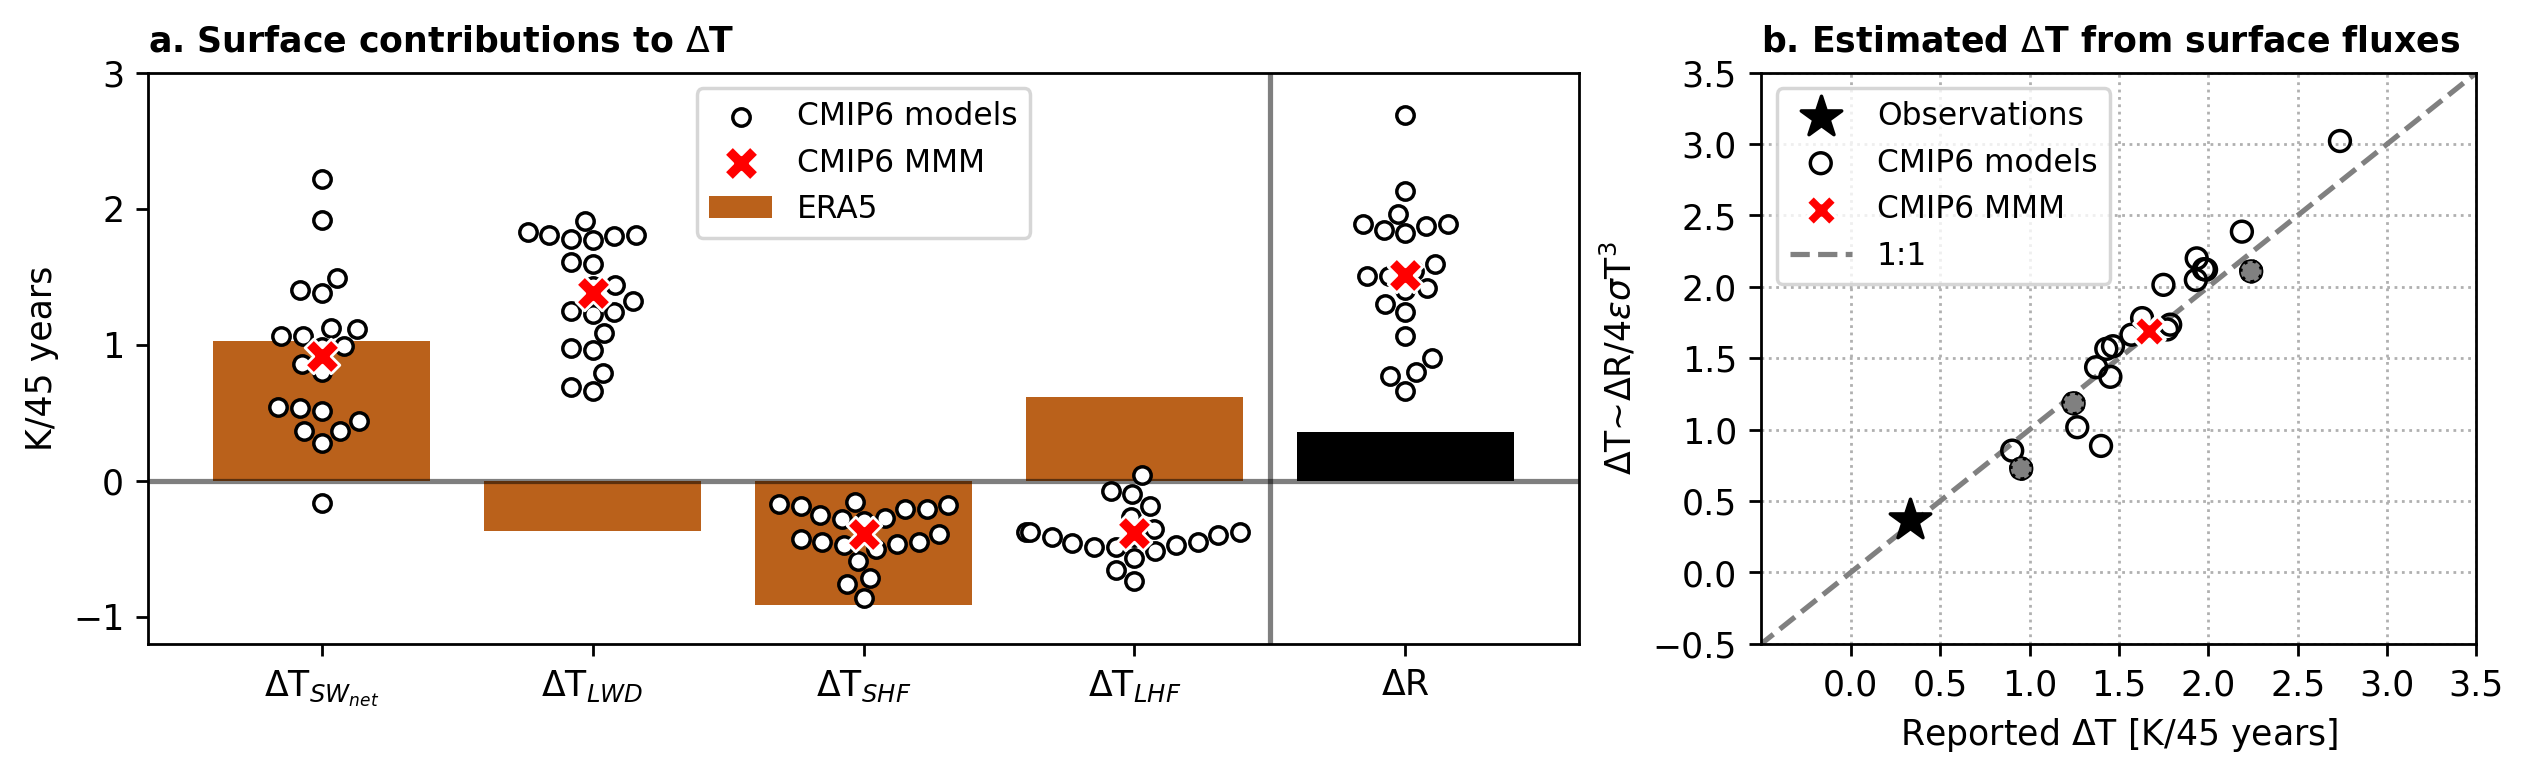

In [106]:
mosaic = """AAC"""
fig = plt.figure(dpi=250, layout='constrained', figsize=(10,3), )
axes = fig.subplot_mosaic(mosaic)

#es = plt.subplot(1,2,1)
sns.swarmplot(data=45*models_plot_dss_means_df.div(4*sigma*(model_temp_wus_80_14_avg_clim_jfm**3), axis=0), ax=axes['A'],  marker = 'o', edgecolor='k', color='white',zorder=5, linewidth=1,label='CMIP6 models')
#sns.swarmplot(data=q_adjusted_lwds.div(4*sigma*(model_temp_wus_avg_clim_jfm**3), axis=0),ax=axes['A'], color='steelblue', marker='+', size=3,linewidth=1, zorder=5)
sns.barplot(data=era5_plot_dss_means_df*45/(4*sigma*(berk_temp_wus_80_14_avg_clim_jfm.item()**3)), ax=axes['A'],palette=['#d55e00', '#d55e00','#d55e00','#d55e00','k'], label='ERA5')
sns.scatterplot(data=45*models_plot_dss_means_df.div(4*sigma*(model_temp_wus_80_14_avg_clim_jfm**3), axis=0).mean(),zorder=20, ax=axes['A'],marker='X', s=100, color='r', label='CMIP6 MMM')
#sns.scatterplot(data=q_adjusted_lwds.div(4*sigma*(model_temp_wus_80_14_avg_clim_jfm**3), axis=0).mean(),ax=axes['A'], color='steelblue', marker='X',s=100, zorder=6, label = 'q-adjusted CMIP6 MMM')


handles, labels = axes['A'].get_legend_handles_labels()
axes['A'].axhline(0, c='k', alpha=0.5)
axes['A'].axvline(3.5, c='k', alpha=0.5)

axes['A'].legend(handles[4:7], labels[4:7], fontsize=9, loc='upper center')
axes['A'].set_ylabel('K/45 years')
axes['A'].set_ylim(-1.2,3)
axes['A'].set_title('a. Surface contributions to $\Delta$T',fontsize=10, fontweight='bold', loc='left')
axes['A'].set_xticklabels(['$\Delta$T$_{SW_{net}}$', '$\Delta$T$_{LWD}$', '$\Delta$T$_{SHF}$','$\Delta$T$_{LHF}$', '$\Delta$R'])

axes['C'].set_xticks(np.arange(0, 6, 0.5))

axes['C'].grid(which='major', alpha=1, ls=':')
axes['C'].set_xlim(-0.5,3.5)
axes['C'].set_ylim(-0.5,3.5)

axes['C'].scatter(y=45*era5_plot_dss_means_df['$\Delta$R']/(4*sigma*(berk_temp_wus_avg_clim_jfm**3)), x=45*berk_temp_wus_avg_trend_szn['JFM'].temperature_polyfit_coefficients, c='k', marker='*', s=150, label='Observations', zorder=5)
axes['C'].scatter(y=(45*models_plot_dss_means_df['$\Delta$R']/(4*sigma*(model_temp_wus_avg_clim_jfm**3))), 
                  x=45*ds_tas_avg_51_80_m_anom_trend_szn['JFM'].tas_wus_polyfit_coefficients.sel(model=(ds_rsns_wus_51_80_m_anom_trend_szn['JFM']).model), marker='o',
                facecolor='None', edgecolors='k', label='CMIP6 models', zorder=5)
axes['C'].scatter(y=45*(models_plot_dss_means_df['$\Delta$R']/(4*sigma*(model_temp_wus_avg_clim_jfm**3))).mean(), x=45*(ds_tas_avg_51_80_m_anom_trend_szn['JFM'].tas_wus_polyfit_coefficients.sel(model=(ds_rsns_wus_51_80_m_anom_trend_szn['JFM']).model)).mean(),
                c='r', marker='X', edgecolor='white',s=80, label='CMIP6 MMM', zorder=5)
#axes['C'].scatter(y=q_adjusted_lwds['$\Delta$R']/(4*sigma*(model_temp_wus_avg_clim_jfm**3)), x=45*ds_tas_avg_51_80_m_anom_trend_szn['JFM'].tas_wus_polyfit_coefficients.sel(model=(ds_rsns_wus_51_80_m_anom_trend_szn['JFM']).model), 
#                facecolor='None', edgecolors='k', label='$q$-adjusted CMIP6 models',c='steelblue', marker='x',linewidth=1, s=30, zorder=6)
axes['C'].scatter(y=(45*models_plot_dss_means_df['$\Delta$R']/(4*sigma*(model_temp_wus_avg_clim_jfm**3))).where(q_adjusted_lwds['$\Delta$R'] != q_adjusted_lwds['$\Delta$R']),
                  x=45*ds_tas_avg_51_80_m_anom_trend_szn['JFM'].tas_wus_polyfit_coefficients.sel(model=(ds_rsns_wus_51_80_m_anom_trend_szn['JFM']).model), marker='o',
                facecolor='grey', edgecolors='k', linestyle=':', label='', zorder=5)

axes['C'].plot(np.arange(-1,6), np.arange(-1,6), c='grey',ls='--', label='1:1')
#sns.regplot(y=45*models_plot_dss_means_df['$\Delta$R']/(4*sigma*(model_temp_wus_avg_clim_jfm**3)), x=45*ds_tas_avg_51_80_m_anom_trend_szn['JFM'].tas_wus_polyfit_coefficients.sel(model=(ds_rsns_wus_51_80_m_anom_trend_szn['JFM']).model),
#           truncate=False, ci=None, scatter=False, color='r', ax=axes['B'], line_kws={'linewidth':1}, label='Model regression')

axes['C'].set_xlabel('Reported $\Delta$T [K/45 years]')
axes['C'].set_ylabel('$\Delta$T~$\Delta$R/4$\epsilon\sigma$T$^3$')
axes['C'].set_title('b. Estimated $\Delta$T from surface fluxes', fontsize=10, fontweight='bold', loc='left')
#axes['B'].set_title('', fontsize=9)

axes['C'].legend(fontsize=9)


## Figure 7

### open dataframe of difference between modeled and observed LWD due to different drivers (see FIGURE6.ipynb where the .pkl files are generated)

In [86]:
cmip6_ensmean_pyrte_df_discrepancy = pd.read_pickle('/home/tessj/wus_temp_trends/cmip6_ensmean_pyrte_df_discrepancy.pkl')
cmip6_ensmean_pyrte_df_discrepancy_means = pd.read_pickle('/home/tessj/wus_temp_trends/cmip6_ensmean_pyrte_df_discrepancy_means.pkl')

In [87]:
cmip6_ensmean_pyrte_df_discrepancy_means.columns = ['Total', 'q contr', 'CRE contr']
cmip6_ensmean_pyrte_df_discrepancy.columns = ['Total', 'q contr', 'CRE contr']

In [145]:
cmip6_ensmean_pyrte_df_discrepancy_means['q and CRE contr'] = cmip6_ensmean_pyrte_df_discrepancy_means['q contr'] + cmip6_ensmean_pyrte_df_discrepancy_means['CRE contr']
cmip6_ensmean_pyrte_df_discrepancy['q and CRE contr'] = cmip6_ensmean_pyrte_df_discrepancy['q contr'] + cmip6_ensmean_pyrte_df_discrepancy['CRE contr']

In [88]:
q_adjusted_lwds = pd.Series(45*models_plot_dss_means_df['$\Delta$LWD'] - cmip6_ensmean_pyrte_df_discrepancy['q contr']).rename('$\Delta$LWD')
q_adjusted_lwds = pd.DataFrame(q_adjusted_lwds)

In [89]:
q_adjusted_lwds['$\Delta$R'] = pd.Series(45*models_plot_dss_means_df['$\Delta$R'] -  cmip6_ensmean_pyrte_df_discrepancy['q contr'])

/tmp/ipykernel_23552/226589016.py:55: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes['B'].set_xticklabels(['CMIP6 - ERA5 \nreported $\Delta$LWD', '$\Delta$LWD$_{qbias}$', '$\Delta$LWD$_{cloud}$', '$\Delta$LWD$_{qbias+cloud}$'])


[Text(0, 0, 'CMIP6 - ERA5 \nreported $\\Delta$LWD'),
 Text(1, 0, '$\\Delta$LWD$_{qbias}$'),
 Text(2, 0, '$\\Delta$LWD$_{cloud}$'),
 Text(3, 0, '$\\Delta$LWD$_{qbias+cloud}$')]

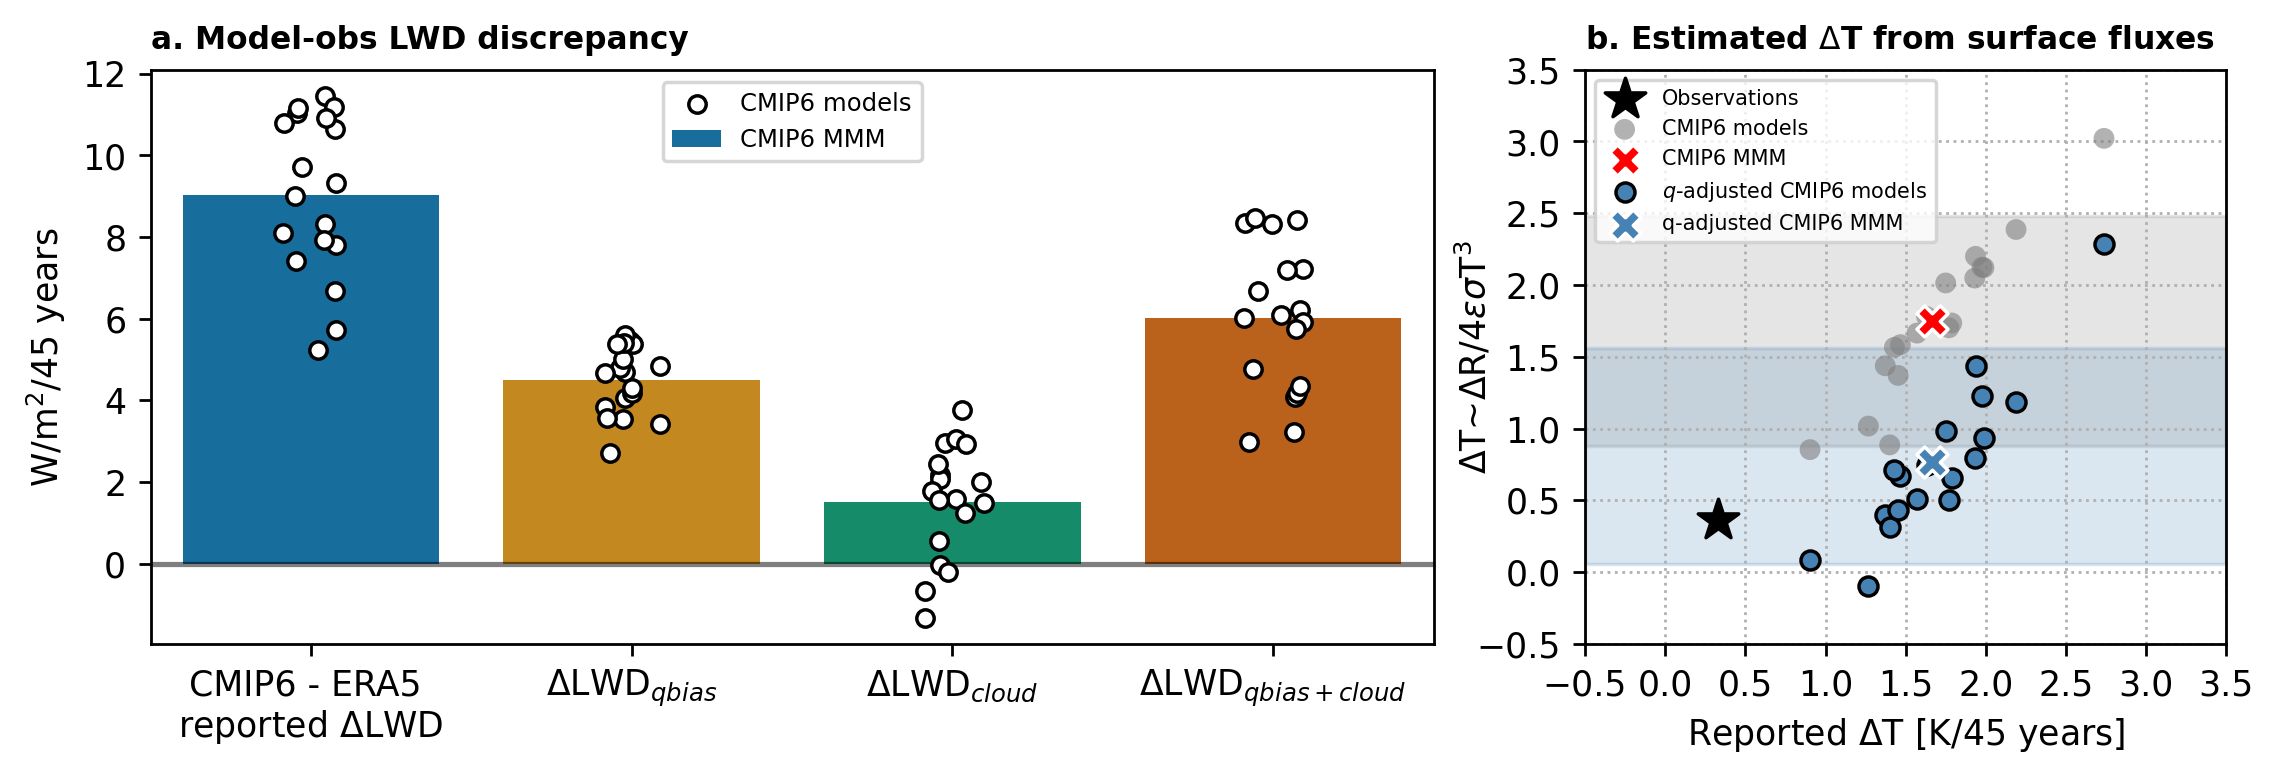

In [172]:
mosaic = """BBC"""
fig = plt.figure(dpi=250, layout='constrained', figsize=(9,3))
axes = fig.subplot_mosaic(mosaic)


#ax = plt.subplot(1,2,2)
axes['C'].set_xticks(np.arange(-0.5, 6, 0.5))

axes['C'].grid(which='major', alpha=1, ls=':')
axes['C'].set_xlim(-0.5,3.5)

axes['C'].scatter(y=45*era5_plot_dss_means_df['$\Delta$R']/(4*sigma*(berk_temp_wus_avg_clim_jfm**3)), x=45*berk_temp_wus_avg_trend_szn['JFM'].temperature_polyfit_coefficients, c='k', marker='*', s=150, label='Observations', zorder=5)
axes['C'].scatter(y=(45*models_plot_dss_means_df['$\Delta$R']/(4*sigma*(model_temp_wus_avg_clim_jfm**3))).where(q_adjusted_lwds['$\Delta$R'] == q_adjusted_lwds['$\Delta$R']), 
                  x=45*ds_tas_avg_51_80_m_anom_trend_szn['JFM'].tas_wus_polyfit_coefficients.sel(model=(ds_rsns_wus_51_80_m_anom_trend_szn['JFM']).model), marker='o',
                facecolor='grey', alpha=0.6, edgecolors='None', label='CMIP6 models', zorder=5)
axes['C'].scatter(y=45*(models_plot_dss_means_df['$\Delta$R']/(4*sigma*(model_temp_wus_avg_clim_jfm**3))).where(q_adjusted_lwds['$\Delta$R'] == q_adjusted_lwds['$\Delta$R']).mean(), x=45*(ds_tas_avg_51_80_m_anom_trend_szn['JFM'].tas_wus_polyfit_coefficients.sel(model=(ds_rsns_wus_51_80_m_anom_trend_szn['JFM']).model)).mean(),
                c='r', marker='X', edgecolor='white',s=80, label='CMIP6 MMM', zorder=5)



axes['C'].scatter(y=q_adjusted_lwds['$\Delta$R']/(4*sigma*(model_temp_wus_avg_clim_jfm**3)), x=45*ds_tas_avg_51_80_m_anom_trend_szn['JFM'].tas_wus_polyfit_coefficients.sel(model=(ds_rsns_wus_51_80_m_anom_trend_szn['JFM']).model), 
                facecolor='steelblue', edgecolors='k', label='$q$-adjusted CMIP6 models', marker='o',linewidth=1, s=30, zorder=6)
axes['C'].axhspan(((45*models_plot_dss_means_df['$\Delta$R'].where(q_adjusted_lwds['$\Delta$R']==q_adjusted_lwds['$\Delta$R'])/(4*sigma*(model_temp_wus_avg_clim_jfm**3)))).dropna().quantile(0.05), 
                 ((45*models_plot_dss_means_df['$\Delta$R'].where(q_adjusted_lwds['$\Delta$R']==q_adjusted_lwds['$\Delta$R'])/(4*sigma*(model_temp_wus_avg_clim_jfm**3)))).dropna().quantile(0.95), color='grey', alpha=0.2)

axes['C'].axhspan((q_adjusted_lwds['$\Delta$R']/(4*sigma*(model_temp_wus_avg_clim_jfm**3))).dropna().quantile(0.05), 
                 (q_adjusted_lwds['$\Delta$R']/(4*sigma*(model_temp_wus_avg_clim_jfm**3))).dropna().quantile(0.95), color='steelblue', alpha=0.2)
#axes['C'].scatter(y=(45*models_plot_dss_means_df['$\Delta$R']/(4*sigma*(model_temp_wus_avg_clim_jfm**3))).where(q_adjusted_lwds['$\Delta$R'] != q_adjusted_lwds['$\Delta$R']),
#                  x=45*ds_tas_avg_51_80_m_anom_trend_szn['JFM'].tas_wus_polyfit_coefficients.sel(model=(ds_rsns_wus_51_80_m_anom_trend_szn['JFM']).model), marker='o',
#                facecolor='grey', edgecolors='k', linestyle=':', label='', zorder=5)
axes['C'].scatter(y=(q_adjusted_lwds['$\Delta$R']/(4*sigma*(model_temp_wus_avg_clim_jfm**3))).dropna().mean(), 
                  x=45*ds_tas_avg_51_80_m_anom_trend_szn['JFM'].tas_wus_polyfit_coefficients.sel(model=(ds_rsns_wus_51_80_m_anom_trend_szn['JFM']).model).mean(),
                c='steelblue', marker='X', edgecolor='white',s=80, label='q-adjusted CMIP6 MMM', zorder=15)
#axes['C'].plot(np.arange(-1,6), np.arange(-1,6), c='grey',ls='--', label='1:1')
#sns.regplot(y=45*models_plot_dss_means_df['$\Delta$R']/(4*sigma*(model_temp_wus_avg_clim_jfm**3)), x=45*ds_tas_avg_51_80_m_anom_trend_szn['JFM'].tas_wus_polyfit_coefficients.sel(model=(ds_rsns_wus_51_80_m_anom_trend_szn['JFM']).model),
#           truncate=False, ci=None, scatter=False, color='r', ax=axes['B'], line_kws={'linewidth':1}, label='Model regression')

axes['C'].set_xlabel('Reported $\Delta$T [K/45 years]')
axes['C'].set_ylabel('$\Delta$T~$\Delta$R/4$\epsilon\sigma$T$^3$', labelpad=-5)
axes['C'].set_title('b. Estimated $\Delta$T from surface fluxes', fontsize=9, fontweight='bold', loc='left')
#axes['B'].set_title('', fontsize=9)

axes['C'].legend(fontsize=6)
axes['C'].set_ylim(-.5,3.5)


sns.barplot(cmip6_ensmean_pyrte_df_discrepancy_means, ax = axes['B'], label='CMIP6 MMM', palette='colorblind')
sns.stripplot(cmip6_ensmean_pyrte_df_discrepancy, marker = 'o', edgecolor='k', color='white', linewidth=1, ax = axes['B'], label='CMIP6 models')
axes['B'].set_title('a. Model-obs LWD discrepancy', fontsize=9, fontweight='bold', loc='left')
axes['B'].set_ylabel('W/m$^2$/45 years')
axes['B'].axhline(0, c='k', alpha=0.5)
axes['B'].legend(fontsize=7)
handles, labels = axes['B'].get_legend_handles_labels()
axes['B'].legend(handles[3:5], labels[3:5], fontsize=7, loc='upper center')
axes['B'].set_xticklabels(['CMIP6 - ERA5 \nreported $\Delta$LWD', '$\Delta$LWD$_{qbias}$', '$\Delta$LWD$_{cloud}$', '$\Delta$LWD$_{qbias+cloud}$'])
